## Lab 2: Fine-tuning Nova-Lite using SageMaker Training Job

**⏱️ Estimated completion time: 10 minutes**

### Lab overview

Brief: This lab demonstrates the complete process of fine-tuning a Nova-Lite model using Amazon SageMaker Training Jobs. You'll learn how to configure training parameters, customize training recipes, launch training jobs, and monitor the training process to create a custom model ready for deployment.

Expected outputs: A successfully trained Nova-Lite model with training artifacts stored in S3, ready for import into Amazon Bedrock for inference.

**Key Learning Objectives:**
- Understand SageMaker Training Job configuration and setup
- Learn how to customize training recipes for specific use cases
- Explore training job monitoring and accessing training artifacts
- Analyze Train/Validation loss curves

**Workshop Progress:**
- ✅ Lab 1: Data Preparation
- ⏳ Lab 2: Fine-tuning Nova-Lite (10 mins)  ← 📍 You are here 
- ⏳ Lab 3: Import & Deploy to Bedrock (5 mins)
- ⏳ Lab 4: Inference & Qualitative Testing (10 mins)
- ⏳ Lab 5: Quantitative Evaluation (5 mins)

### 🎯 Workshop Context

In this lab, you'll take preprocessed data from Lab1 and use it to fine-tune a Nova-Lite model. The training process uses SageMaker's managed infrastructure to handle the computational requirements while you focus on configuring the training parameters and monitoring progress.

**Why use SageMaker Training Jobs?**
- Managed infrastructure with automatic scaling
- Built-in support for distributed training 
- Integration with other AWS services
- Cost-effective training with spot instances
- Comprehensive logging and monitoring

### Prerequisites
- You have already run Lab 1.


### 1 — Environment setup and library imports

Brief: Import essential Python libraries and modules required for SageMaker training job configuration and execution. These libraries provide the foundation for interacting with AWS services and managing the training workflow.

Why we're doing this: We need these libraries to create and manage SageMaker training jobs, handle AWS authentication, and interact with S3 storage. Each library serves a specific purpose in the training pipeline.

What to check after running: Verify no import errors occur and all required libraries are available in your environment.

References:
- [SageMaker Python SDK Documentation](https://sagemaker.readthedocs.io/)
- [Boto3 Documentation](https://boto3.amazonaws.com/v1/documentation/api/latest/index.html)


⚠️ Note: 

Please select the following **Python Environment** to run this notebook.

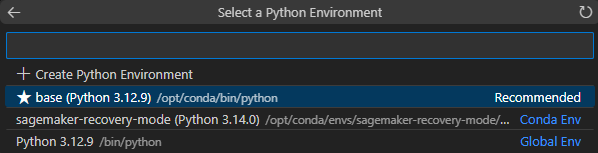


In [ ]:
import os
import json
import boto3
import sagemaker
from sagemaker import get_execution_role

### 2 — Configure SageMaker session and execution role

Brief: Initialize the SageMaker session and retrieve the execution role that will be used for training job permissions. The execution role must have appropriate permissions to access S3, create training jobs, and manage SageMaker resources.

Why we're doing this: SageMaker training jobs require an IAM role with specific permissions to access training data in S3, write model artifacts, and manage compute resources. The session establishes our connection to the SageMaker service.

What to check after running: Verify the role ARN is displayed.


In [ ]:
region_name = boto3.Session().region_name
sm_client = boto3.client("sagemaker", region_name=region_name)
sagemaker_session = sagemaker.session.Session(
    boto_session=boto3.session.Session(), sagemaker_client=sm_client
)
role_arn = get_execution_role()
role_arn

### 3 — Clone training recipe repository

Brief: Clone the SageMaker Hyperpod recipes repository which contains pre-configured training recipes for various models including Nova-Lite. These recipes provide optimized training configurations and hyperparameters.

Why we're doing this: Training recipes contain battle-tested configurations that have been optimized for specific model architectures and use cases. Using these recipes saves time and ensures we start with proven hyperparameters and training settings.

What to check after running: Verify in the output that the repository is cloned successfully and the recipes directory contains the Nova-Lite training configuration files.

📝 Note: You can modify training recipes to customize hyperparameters, instance types, and other training parameters as needed for your specific use case.


In [ ]:
%%bash
if [ ! -d "sagemaker-hyperpod-recipes" ]; then
  git clone --recurse-submodules https://github.com/aws/sagemaker-hyperpod-recipes.git
else
  echo "sagemaker-hyperpod-recipes already cloned. Skipping."
fi

### 4 — Set up training recipe configuration

Brief: Copy the Nova-Lite training recipe to a new "recipes" directory and configure the recipe path. This recipe contains all the hyperparameters, model configuration, and training settings needed for fine-tuning.

Why we're doing this: The training recipe acts as a blueprint for our training job, defining everything from learning rates to batch sizes. By copying it locally, we can customize it for our specific requirements while maintaining the base configuration.

What to check after running: Verify the recipe file is copied to the recipes directory and the recipe_path variable points to the correct location.


In [ ]:
%%bash 
mkdir -p recipes
cp ./sagemaker-hyperpod-recipes/recipes_collection/recipes/fine-tuning/nova/nova_1_0/nova_lite/SFT/nova_lite_1_0_g5_g6_12x_gpu_lora_sft.yaml ./recipes/


This recipe can be modified to change any of the training configs. 

In [ ]:
recipe_path = "./recipes/nova_lite_1_0_g5_g6_12x_gpu_lora_sft.yaml"

<div style='background-color: #f3e5f5; border-left: 4px solid #9c27b0; padding: 15px; margin: 10px 0;'>
<h3 style='color: #7b1fa2; font-family: Arial, sans-serif; margin-top: 0;'>📋 Your Task:</h3>
<ul style='color: #333; font-family: Arial, sans-serif; font-size: 14px;'>
<li>Open the recipe file and modify max_epochs to 1 for faster training during this workshop</li>
<li>This reduces training time while still demonstrating the complete workflow</li>
<li>In production, you would typically use more epochs for better model performance</li>
</ul>
</div>


### 5 — Configure SageMaker training job parameters

Brief: Set up the essential parameters for the SageMaker training job including S3 paths, container image, and compute resources. These parameters define where the training data is located, where outputs will be stored, and what compute resources to use.

Why we're doing this: SageMaker training jobs require specific configuration to know where to find training data, where to store outputs, and what compute resources to provision. Proper configuration ensures efficient training and cost optimization.

What to check after running: Verify all S3 paths are correctly set, the container image URI is valid, and the instance type matches your requirements and quotas.

Key parameters we need to specify:
1. S3 buckets and prefixes for training data and outputs (must be in the same region)
2. IAM role ARN for training permissions and S3 access
3. Docker container image URI for Nova fine-tuning

References: [SageMaker IAM Roles Documentation](https://docs.aws.amazon.com/sagemaker/latest/dg/sagemaker-roles.html#sagemaker-roles-get-execution-role-s3)


Let's retrieve the S3 URIs and training parameters from the data preparation notebook using SageMaker's variable storage mechanism.


In [ ]:
%store -r train_dataset_s3_path val_dataset_s3_path test_dataset_s3_path output tensorboard
train_dataset_s3_path, val_dataset_s3_path, test_dataset_s3_path, output, tensorboard

### 6 — Configure training job parameters and resources

Brief: Set up the training job configuration including job name, S3 paths, container image, instance type, and TensorBoard logging. These parameters define the complete training environment and resource allocation.

Why we're doing this: Each parameter serves a specific purpose in the training pipeline - from identifying the job to configuring compute resources and enabling monitoring through TensorBoard integration.


In [ ]:
from sagemaker.debugger import TensorBoardOutputConfig

base_job_name = "nova-lite-docvqa" # Name of the sagemaker training job 

input_s3_uri = train_dataset_s3_path  # Specify S3 URI of the input training dataset

validation_s3_uri = val_dataset_s3_path # Specify S3 URI of the input validation dataset

output_s3_uri = output  # Specify S3 URI of where all the training output will be available

image_uri = f"708977205387.dkr.ecr.{sagemaker_session.boto_region_name}.amazonaws.com/nova-fine-tune-repo:SM-TJ-SFT-latest"

instance_type = "ml.g5.12xlarge" # Training instance 

# Specify S3 URI for TensorBoard logging
tensorboard_output_path = tensorboard
tensorboard_output_config = TensorBoardOutputConfig(
    s3_output_path=os.path.join(tensorboard_output_path, "tensorboard"),
)

### 7 — Create SageMaker PyTorch Estimator

Brief: Initialize the SageMaker PyTorch Estimator with all the configured parameters. The estimator is the main interface for managing training jobs and encapsulates all training configuration.

Why we're doing this: The PyTorch Estimator provides a high-level interface to SageMaker training jobs, handling the complexity of container management, resource provisioning, and job orchestration while giving us fine-grained control over training parameters.

Reference: [SageMaker PyTorch Estimator Documentation](https://sagemaker.readthedocs.io/en/stable/api/training/estimators.html)


⚠️ Note:

If ml.g5.12xlarge is unavailable you can use ml.g5.2xlarge instead.

Generally, the ml.g5.12xlarge training instance provides a good balance of performance and cost. 

However, using more powerful instances like ml.p5.48xlarge can perform the training job much faster.

In [ ]:
from sagemaker.pytorch import PyTorch

estimator = PyTorch(
    image_uri=image_uri,
    base_job_name=base_job_name,
    role=role_arn,
    instance_type=instance_type,
    training_recipe=recipe_path,
    sagemaker_session=sagemaker_session,
    output_path=output_s3_uri,
    tensorboard_output_config=tensorboard_output_config, 
)

Lastly, specify the training and validation data input channels. 

In [ ]:
from sagemaker.inputs import TrainingInput

trainingInput = TrainingInput(
    s3_data=input_s3_uri,
    distribution="FullyReplicated",
    s3_data_type="Converse" 
)

validationInput = TrainingInput(
        s3_data=validation_s3_uri,
        distribution="FullyReplicated",
        s3_data_type="Converse",
)

## 6. Launch the training job

Now kick-off the training job! 

In [ ]:
estimator.fit(inputs={"train": trainingInput, "validation": validationInput})

So what's happening here ?

- SageMaker will automatically deploy the EC2 training instance with the Nova fine-tuning container
- Download the training/validation datasets from S3 to the container
- Perform model fine-tuning 
- Save the fine-tuned model to an **Escrow S3 bucket**. 

⚠️ Important Note: 

- The fine tuned model is stored in an AWS managed escrow account and NOT in your account. 

- Only the training artifacts like metadata and training/validation loss are available in your account's S3 bucekt (i.e output S3 URI).


The training environment setup will take about 15-20 mins and only then you will start seeing the training epochs, training loss, validation loss etc as part of the logs. 

The entire training process can take several hours depending on the size of the dataset, number of epochs and training instance selected. 

As part of training it is very important to observe the training and validation loss curves as the epochs progress to prevent overfitting or underfitting. 
For more information, see- [Overfitting v/s Underfitting](https://aws.amazon.com/what-is/overfitting/).

The data science techniques of improving model accuracy by reducing training/validation loss involves tuning the hyperparmeters provided in the training recipe, which is out of scope of this workshop. For more information, see- [Nova-fine-tune-peft](https://docs.aws.amazon.com/sagemaker/latest/dg/nova-fine-tune.html#nova-fine-tune-peft) 
 

## 7. Monitoring the Training Job in SageMaker Studio

You can monitor the progress and status of your training job directly within the SageMaker Studio UI, or using the SageMaker `describe_training_job` API.


<div style='background-color: #f3e5f5; border-left: 4px solid #9c27b0; padding: 15px; margin: 10px 0;'>
<h3 style='color: #7b1fa2; font-family: Arial, sans-serif; margin-top: 0;'>📋 Your Task :</h3>
<ul style='color: #333; font-family: Arial, sans-serif; font-size: 14px;'>
<li>Monitor the Training Job you just started in Step 6</li>
</ul>



***1. In Studio, navigate to the **Jobs** pane and choose **Training**.*** 

***2. Select your training job starting with **`nova-lite-docvqa-`** from the list to view real-time performance, job status, and resource utilization.***

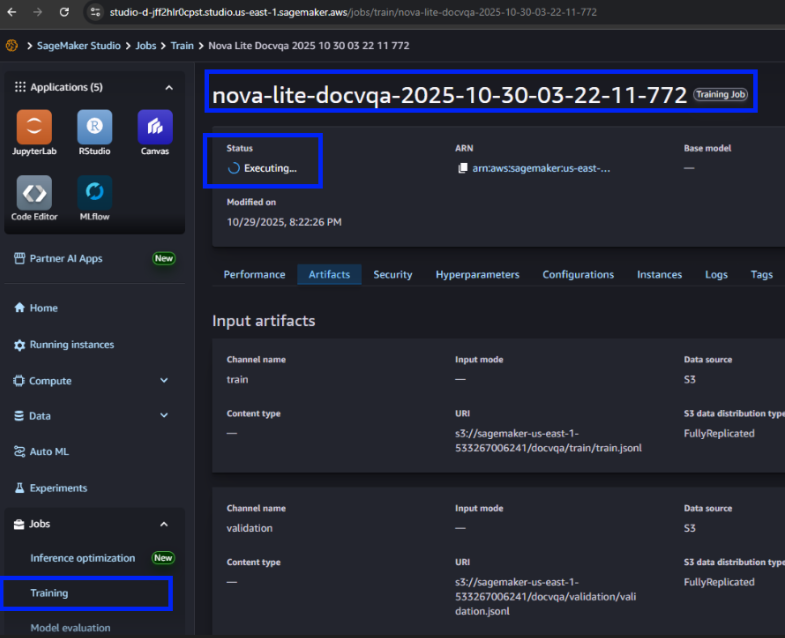

For advanced metrics and visualizations you can also use Sagemaker Tensorboard, refer to [SageMaker TensorBoard documentation](https://docs.aws.amazon.com/sagemaker/latest/dg/debugger-htb-access-tb.html).

## 8. Explore the Output of the prerun Training Job 

For this workshop we have already prerun a Sagemaker fine-tuning job. Lets explore the results we got from the previous training job.

<div style='background-color: #f3e5f5; border-left: 4px solid #9c27b0; padding: 15px; margin: 10px 0;'>
<h3 style='color: #7b1fa2; font-family: Arial, sans-serif; margin-top: 0;'>📋 Your Task :</h3>
<ul style='color: #333; font-family: Arial, sans-serif; font-size: 14px;'>
<li>Stop the training job you just started in Step 6.</li>
</ul>



***1. First stop the notebook cell in step 6***
   
   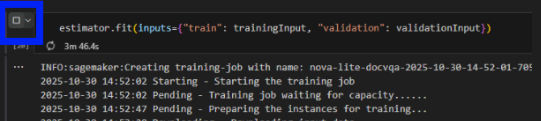


***2. Next, stop the training job in Sagemaker studio UI.***

   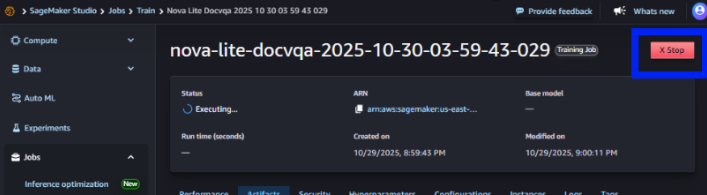

<div style='background-color: #f3e5f5; border-left: 4px solid #9c27b0; padding: 15px; margin: 10px 0;'>
<h3 style='color: #7b1fa2; font-family: Arial, sans-serif; margin-top: 0;'>📋 Your Task :</h3>
<ul style='color: #333; font-family: Arial, sans-serif; font-size: 14px;'>
<li> Examine the results of the prerun training job </li>
</ul>


***1. Go to back Sagemaker studio UI and examine the results of the prerun training job.***

***2. The prerun training job starts with `nova-train-prerun-` as shown below.***

***3. You can explore the full training logs under "Logs".***

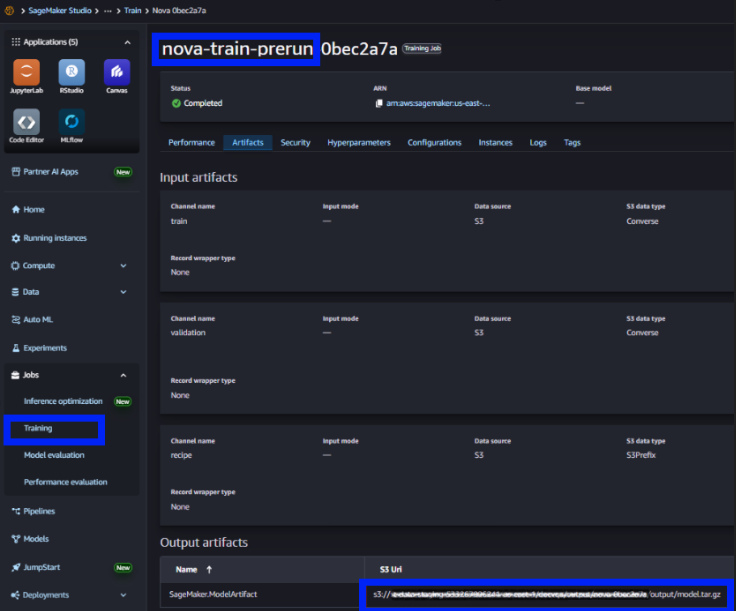

<div style='background-color: #f3e5f5; border-left: 4px solid #9c27b0; padding: 15px; margin: 10px 0;'>
<h3 style='color: #7b1fa2; font-family: Arial, sans-serif; margin-top: 0;'>📋 Your Task :</h3>
<ul style='color: #333; font-family: Arial, sans-serif; font-size: 14px;'>
<li> Copy the output S3 URI under Output artifacts and paste the S3 URI below </li>
</ul>


In [ ]:
# Paste your Output S3 URI below"

model_s3_uri = "Paste here"

output_s3_uri = "/".join(model_s3_uri.split("/")[:-1])+"/output.tar.gz"

output_s3_uri

## 9. Download and Extract the Artifacts

In [ ]:
!mkdir -p ./train_output/

In [ ]:
!aws s3 cp $output_s3_uri ./train_output/output.tar.gz

In [ ]:
!tar -xvzf ./train_output/output.tar.gz -C ./train_output/

⚠️ Important Note:

The fine-tuned model checkpoint is saved in the below escrow account S3 URI. 

In [ ]:
escrow_model_uri = json.load(open('./train_output/manifest.json'))['checkpoint_s3_bucket']
escrow_model_uri

We will store the URI so we can use it in the subsequent notebooks!

In [ ]:
%store escrow_model_uri

## 10. Plotting the Train and Validation Loss Curve 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV files
train_df = pd.read_csv('./train_output/step_wise_training_metrics.csv')
val_df = pd.read_csv('./train_output/validation_metrics.csv')

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_df['step_number'], train_df['training_loss'], label='Training Loss', color='blue')
plt.plot(val_df['step_number'], val_df['validation_loss'], label='Validation Loss', color='red')

plt.xlabel('Step Number')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We are mainly interested to see the validation loss reduction. Lets zoom in to see that. 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV files
train_df = pd.read_csv('./train_output/step_wise_training_metrics.csv')
val_df = pd.read_csv('./train_output/validation_metrics.csv')

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_df['step_number'], train_df['training_loss'], label='Training Loss', color='blue', alpha=0.3)
plt.plot(val_df['step_number'], val_df['validation_loss'], label='Validation Loss', color='red')

# Set y-axis limits based on validation loss range
val_min = val_df['validation_loss'].min()
val_max = val_df['validation_loss'].max()
# Add small padding (10%) to make the visualization clearer
padding = (val_max - val_min) * 0.1
plt.ylim(val_min - padding, val_max + padding)

plt.xlabel('Step Number')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Zoomed on Validation)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


⚠️ Important Note:

During the prerun we ran the fine-tuning job with 1000 training images, 100 validation images and 4 Epochs.

As you can see, the validation loss seems to be diverging after 4 epochs. Hence, we stopped further training.

This model checkpoint is what we saved in ***escrow_model_uri*** above. 

Next, we are going to import and deploy this version of the fine-tuned model on Bedrock in the next notebook.

## 🎉 Lab 2 Complete!

**Congratulations!** You have successfully completed the Amazon Nova fine-tuning training phase. Here's what you accomplished:

### ✅ Tasks Completed:
1. **Training Infrastructure** - Set up SageMaker training environment and dependencies
2. **Model Configuration** - Defined Nova fine-tuning parameters and hyperparameters  
3. **Data Integration** - Connected processed DocumentVQA dataset from Lab 1
4. **Training Launch** - Initiated and monitored fine-tuning job
5. **Progress Tracking** - Implemented metrics collection and visualization
6. **Artifact Management** - Set up model checkpoint and output storage
7. **Performance Monitoring** - Tracked training progress and validation metrics
8. **Documentation** - Recorded training configurations and outcomes

### 📁 Key Outputs:
- **Fine-tuned Model**: Nova model specialized for DocumentVQA
- **Training Metrics**: Loss curves and evaluation statistics
- **Model Artifacts**: Checkpoints saved to S3
- **Training Logs**: Detailed progress and debugging information
- **Configuration Files**: Saved hyperparameters and settings

### 🚀 Next Step:
- **Model Deployment**: Import and deploy the custom model on Amazon Bedrock 

### **Ready for deployement? Proceed to Lab 3!**
